In [1]:
from coffea.nanoevents import NanoAODSchema
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

import dask

from analysis_tools.processors.test_processor import TestProcessor


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
import gzip
import json
import os

# Define the base directory where the preprocessed files are stored
base_dir = "/home/cms-jovyan/dwg_analysis/tools/preprocessing/preprocessed"
signal_sample = "2023_SlepSnu_MN1_270_100000_preprocessed_available.json.gz"
background_sample = "2023_ttbar_100000_preprocessed_available.json.gz"
signal_file_path = os.path.join(base_dir, signal_sample)
background_file_path = os.path.join(base_dir, background_sample)
#print(preprocessed)

with gzip.open(signal_file_path, "rt") as file:
    signal_preprocessed_available = json.load(file)
with gzip.open(background_file_path, "rt") as file:
    background_preprocessed_available = json.load(file)

In [3]:
signal_test_preprocessed_files = max_files(signal_preprocessed_available, 3)
signal_test_preprocessed = max_chunks(signal_test_preprocessed_files, 3)

### SWITCH HERE ###

signal_reduced_computation = True

###################

# signal

if signal_reduced_computation:
    small_tg, small_rep = apply_to_fileset(
        data_manipulation=TestProcessor(),
        fileset=signal_test_preprocessed,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(small_tg, small_rep)
    
else:
    full_tg, full_rep = apply_to_fileset(
        data_manipulation=TestProcessor(),
        fileset=signal_preprocessed_available,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(full_tg, full_rep)


In [4]:
signal_results = signal_computed['/SlepSnuCascade_MN1-270_MN2-280_MC1-275_TuneCP5_13p6TeV_madgraphMLM-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v6-v3/NANOAODSIM']
signal_results

{'counts': {'count_obj_test': 228295,
  'count_obj_events_test': 154274,
  'count_obj_and_events_test': (228295, 154274)},
 'pt_binned': {},
 'calculations': {},
 'plots': {'ele_pt_dist': Hist(Regular(1000, 5, 200, name='pt_dist'), storage=Double()) # Sum: 227142.0 (228295.0 with flow),
  'ele_pt_eta_dist': Hist(
    Regular(100, 0, 10, name='pt'),
    Regular(100, -3, 3, name='eta'),
    storage=Double()) # Sum: 59531.0 (228295.0 with flow),
  'hoe_dist_baseline': Hist(Regular(100, 0, 1.2, name='hoe_dist'), storage=Double()) # Sum: 143822.0 (143846.0 with flow),
  'hoe_dist_gold': Hist(Regular(100, 0, 1.2, name='hoe_dist'), storage=Double()) # Sum: 72935.0,
  'baseline_hoe_pt_dist': Hist(
    Regular(60, 5, 35, name='pt'),
    Regular(60, 0, 1.2, name='hoe'),
    storage=Double()) # Sum: 98529.0 (143846.0 with flow),
  'gold_hoe_pt_dist': Hist(
    Regular(60, 5, 35, name='pt'),
    Regular(60, 0, 1.2, name='hoe'),
    storage=Double()) # Sum: 44239.0 (72935.0 with flow)},
 'tests': {

In [5]:
import matplotlib.pyplot as plt
import mplhep
#have to call this a second time to get proper scaling, a known bug
mplhep.style.use(mplhep.style.CMS)
plt.figure()
mplhep.style.use(mplhep.style.CMS)

<Figure size 1000x1000 with 0 Axes>

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fece93ef860>, errorbar=None, legend_artist=None)]

<Figure size 1000x1000 with 0 Axes>

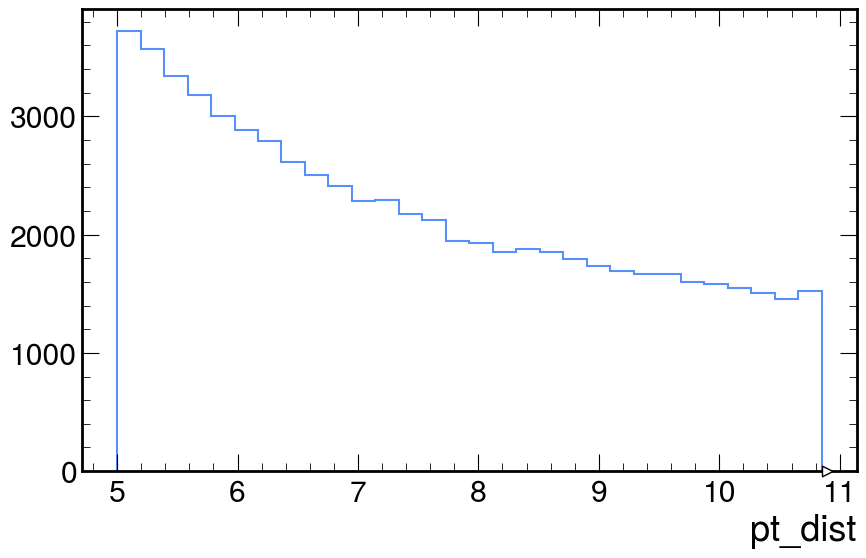

In [6]:
hist_obj = signal_results['plots']['ele_pt_dist']

display_bins = hist_obj[0:30]
plt.figure()
fig, ax = plt.subplots(figsize=(10, 6))
display_bins.plot1d(ax=ax, label="test")

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fece97f4cb0>, errorbar=None, legend_artist=None)]

<Figure size 1000x1000 with 0 Axes>

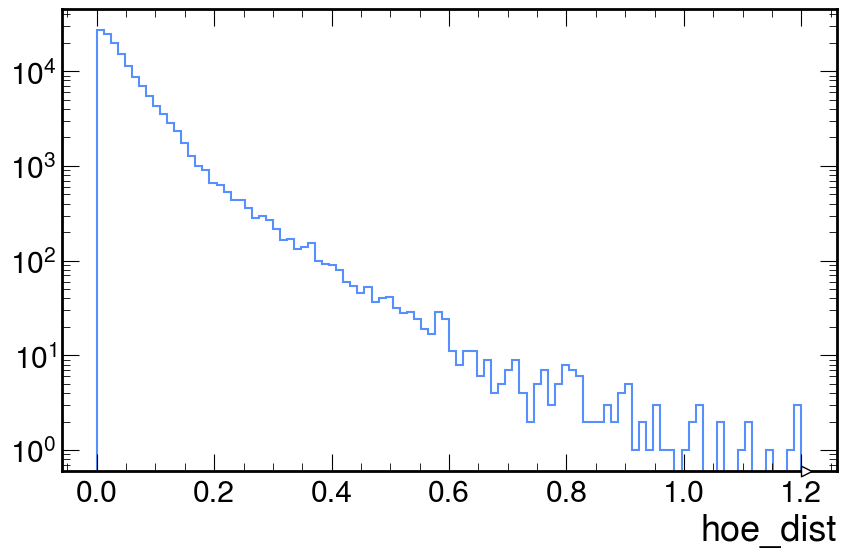

In [8]:
hist_obj_baseline = signal_results['plots']['hoe_dist_baseline']

plt.figure()

fig, ax = plt.subplots(figsize=(10, 6))
plt.yscale("log")

hist_obj_baseline[0:100].plot()


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fece9e4b710>, errorbar=None, legend_artist=None)]

<Figure size 1000x1000 with 0 Axes>

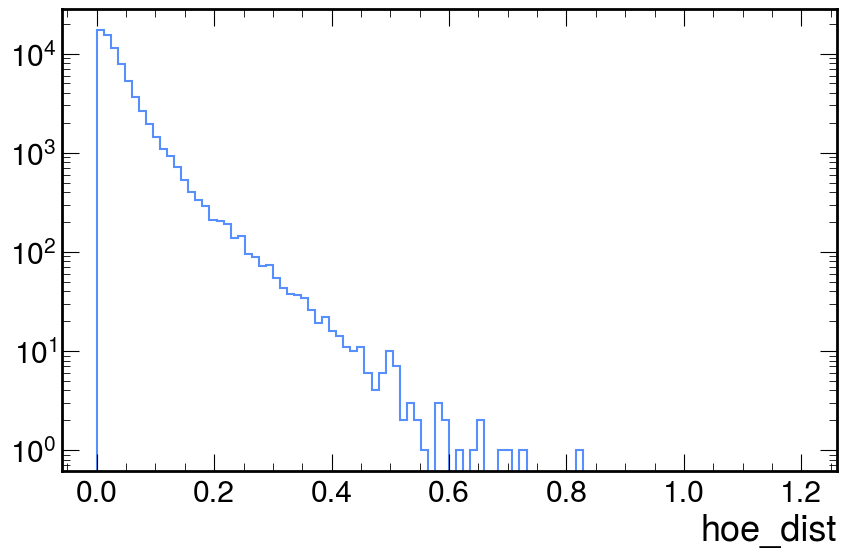

In [9]:
hist_obj_gold = signal_results['plots']['hoe_dist_gold']

plt.figure()

fig, ax = plt.subplots(figsize=(10, 6))
plt.yscale("log")

hist_obj_gold[0:100].plot()


ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fed0a169d30>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fece933d5e0>, text=[])

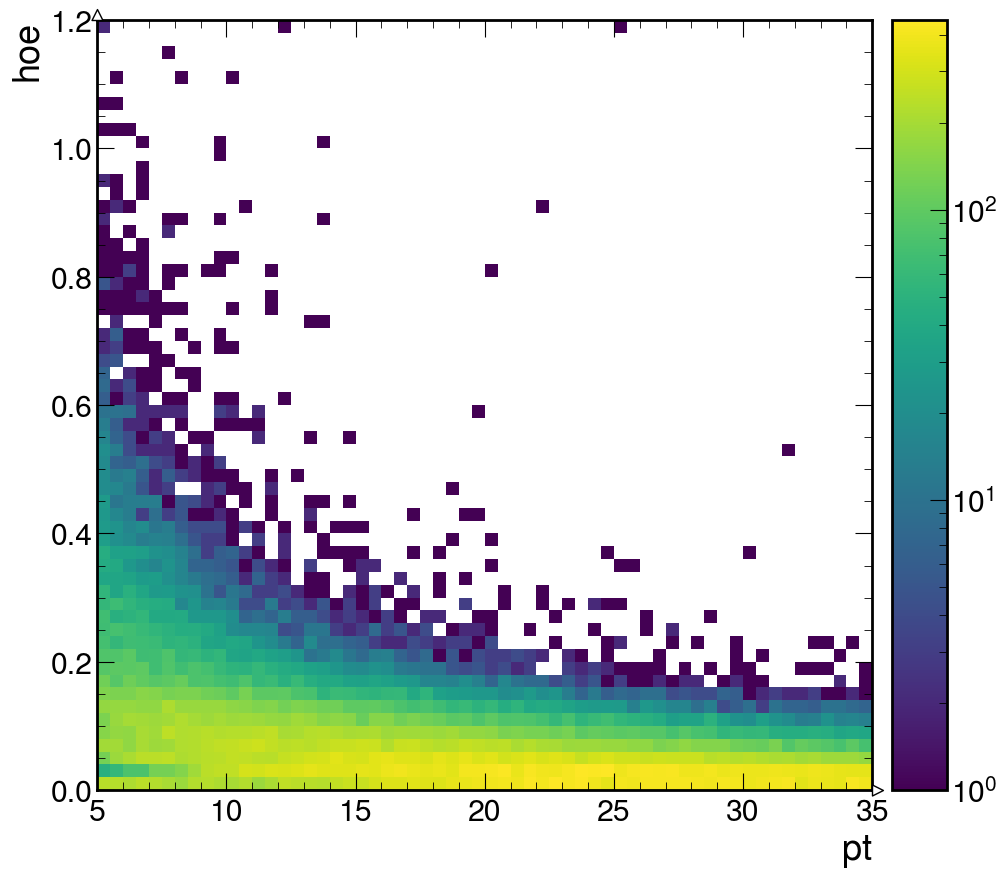

In [10]:
twod_baseline = signal_results['plots']['baseline_hoe_pt_dist']

#plt.figure()

#fig, ax = plt.subplots(figsize=(10, 6))

twod_baseline.plot2d(norm=colors.LogNorm())


ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fece97f6cf0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fece9ad82f0>, text=[])

<Figure size 1000x1000 with 0 Axes>

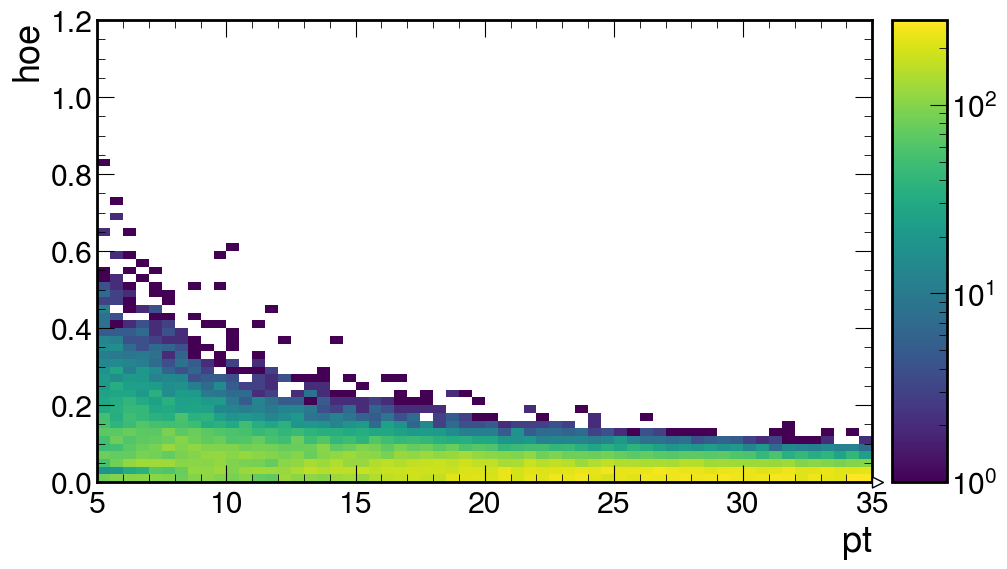

In [11]:
twod_gold = signal_results['plots']['gold_hoe_pt_dist']

plt.figure()

fig, ax = plt.subplots(figsize=(10, 6))

#twod_gold[0:60, 0:30].plot(norm=colors.LogNorm())
twod_gold.plot(norm=colors.LogNorm())

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7feccbee4da0>, errorbar=None, legend_artist=None)]

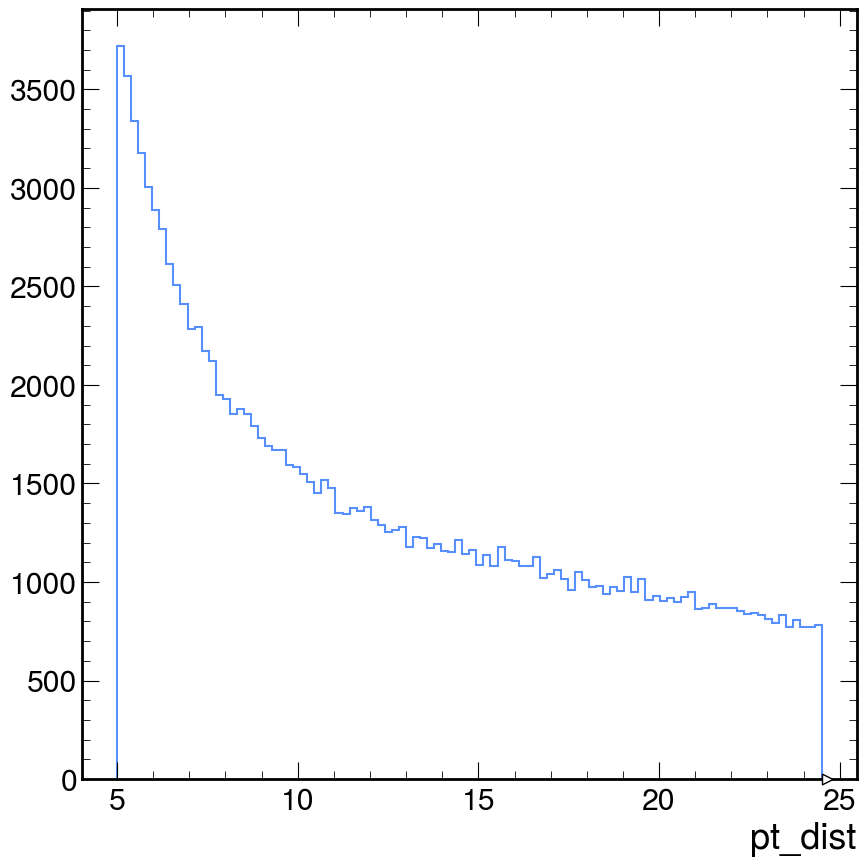

In [12]:
signal_results['plots']['ele_pt_dist'][0:100].plot1d()

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fed0d4d5310>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fece8e93950>, text=[])

<Figure size 1000x1000 with 0 Axes>

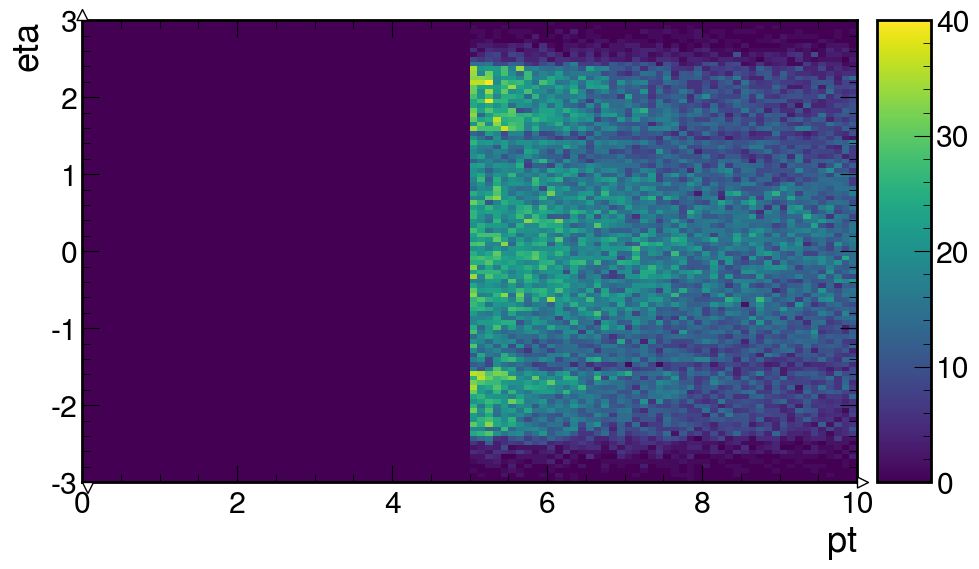

In [13]:
hist_obj = signal_results['plots']['ele_pt_eta_dist']

plt.figure()
fig, ax = plt.subplots(figsize=(10, 6))
hist_obj.plot2d(ax=ax, label="test")
#hist_obj.plot2d(ax=ax, label="test")

(ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7feceb43e6f0>, cbar=None, text=[]),
 [StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fecea0488c0>, errorbar=None, legend_artist=None)],
 [StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7feccbed4980>, errorbar=None, legend_artist=None)])

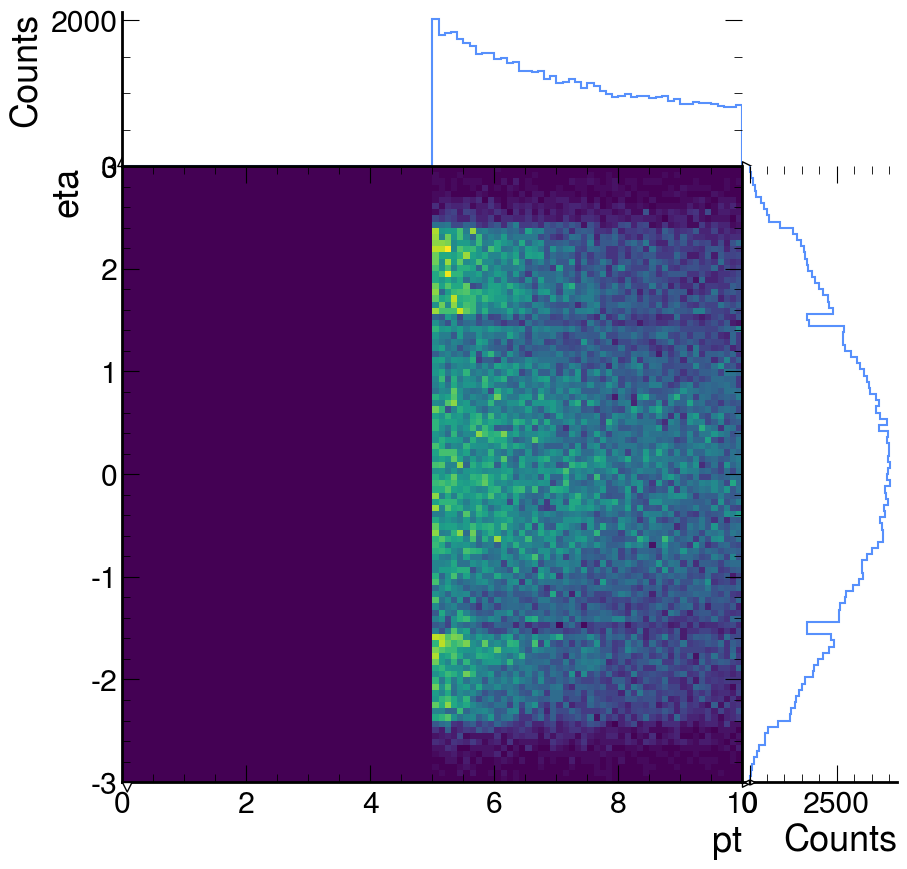

In [14]:
hist_obj = signal_results['plots']['ele_pt_eta_dist']

hist_obj.plot2d_full()
#hist_obj.plot2d(ax=ax, label="test")

In [15]:
hist_obj.axes

(Regular(100, 0, 10, name='pt'), Regular(100, -3, 3, name='eta'))

In [16]:
hist_obj.axes.name[0]

'pt'